<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/%E2%98%85uncomtrade_DLdata_2013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [280]:
# メモ、uncomtradeの2023年  all to all export data (downloaded by free)の格納場所
# C:\Users\haruk\AppData\Local\Temp\MicrosoftEdgeDownloads\f2db363a-9fa7-4d1f-81f2-4c0aba57e591

ダウンロードデータバージョン。
UNComtradeのAPIはいつrejectされるかわからないので、UNComtradeのサイトから無料ダウンロードしたデータ（輸出国・相手国：指定なし、HS：HS28、2023年）を使用


cord source: https://github.com/uncomtrade/comtradeapicall

## 0. 準備

In [281]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import scipy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import io
import os

## 1-1. データダウンロード

## 1-1-1. 今回はExcelでダウンロードしたデータをとりあえず使う

In [282]:
# 使わない！！！
#file_path = "C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/download.csv"
#if os.path.exists(file_path):
    #print("ファイルが見つかりました")
#else:
    #print("ファイルが見つかりません")


In [283]:
# file_path = r"C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/sotsuron/ex_2018_all_all_HS28_dlbyfree.xlsx"
# df = pd.read_excel(file_path)
# print(df.head())

## 1-1-2 データダウンロード別方法で

In [284]:
# 違う方法でダウンロード
import networkx as nx
from google.colab import files
uploaded = files.upload()

Saving ex_2013_all_all_HS28_dlbyfree.xlsx to ex_2013_all_all_HS28_dlbyfree.xlsx


## 1-2. データフレーム化

In [285]:
# アップロードされたファイル名を取得
file_name = list(uploaded.keys())[0]

# ExcelファイルをPandasデータフレームに変換
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# データフレームを確認
df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20130101,2013,52,2013,36,AUS,Australia,X,...,NaN,False,NaN,False,NaN,682491.0,682491.0,0,True,False
1,C,A,20130101,2013,52,2013,36,AUS,Australia,X,...,NaN,False,NaN,False,NaN,8262.0,8262.0,0,True,False
2,C,A,20130101,2013,52,2013,36,AUS,Australia,X,...,NaN,False,NaN,False,NaN,94616.0,94616.0,0,True,False
3,C,A,20130101,2013,52,2013,36,AUS,Australia,X,...,NaN,False,NaN,False,NaN,33320.0,33320.0,0,True,False
4,C,A,20130101,2013,52,2013,36,AUS,Australia,X,...,NaN,False,NaN,False,NaN,28832040.0,28832040.0,0,True,False


##1-2　データ解説

**Selection Criteria**
- typeCode(str) : Product type. Goods (C) or Services (S)
- freqCode(str) : The time interval at which observations occur. Annual (A) or Monthly (M)
- clCode(str) : Indicates the product classification used and which version (HS, SITC)
- period(str) : Combination of year and month (for monthly), year for (annual)
- reporterCode(str) : The country or geographic area to which the measured statistical phenomenon relates
- cmdCode(str) : Product code in conjunction with classification code
- flowCode(str) : Trade flow or sub-flow (exports, re-exports, imports, re-imports, etc.)
- partnerCode(str) : The primary partner country or geographic area for the respective trade flow
- partner2Code(str) : A secondary partner country or geographic area for the respective trade flow
- customsCode(str) : Customs or statistical procedure
- motCode(str) : The mode of transport used when goods enter or leave the economic territory of a country

### 抽出指定
商品データ、年次、HSコード、2023年、報告国は指定なし、品目は HSCode28_Inorganic chemicals; organic or inorganic compounds of precious metals, of rare-earth metals, of radioactive elements or of isotopes （無機化学品及び貴金属、希土類金属、放射性元素又は同位元素の無機又は有機の化合物）、輸出データ、貿易相手国は指定なし、積送国の指定なし、税関コード指定なし、貿易手段指定なし

### 詳説
**typeCode='C':**
これは、データのタイプを示します。'C' はコモディティ（商品）データを意味します。

**freqCode='A':**
データの頻度を指定します。'M'は「月次データ」を意味します。年次データであれば 'A' になります。

**clCode='HS':**
使用される商品分類コードを指定します。'HS'は「Harmonized System（国際統一商品分類）」を指します。この場合、HSコードに基づいた商品データを取得します。

**period='2023':**
データの期間（年）を指定します。ここでは2023年のデータを要求しています。

**reporterCode='156':**
報告国（データを提供している国）のコードです。'156' は中国を意味します。

**cmdCode='21':**
商品コードを指定します。'21' はHSコードで特定の商品カテゴリを表しています。この場合、HSコードの21に該当する商品（レアアース）についてのデータを取得しています。

**flowCode='X':**
貿易フローを指定します。'X'は「輸出」を意味し、輸出データを取得することを指します。'M'であれば輸入データを指定します。

**partnerCode=None:**
貿易相手国のコードです。None と指定されているので、特定の相手国に限定せず、全パートナー国を対象にします。

**partner2Code=None:**
追加の貿易相手国コード（例: 貿易ハブを経由する場合）ですが、Noneに設定されています。

**customsCode=None:**
税関コードを指定します。None なので特定の税関コードを使用しません。

**motCode=None:**
貿易手段（モード・オブ・トランスポート）のコードです。Noneなので、特定の輸送手段に限定しません。

**maxRecords=500:**
取得するデータの最大レコード数です。ここでは、最大500件のデータを取得するように指定されています。

**format_output='JSON':**
データの出力形式を指定します。ここでは、'JSON'形式でデータを取得するようにしています。他にCSV形式などが利用可能な場合もあります。

**aggregateBy=None:**
データの集計方法を指定しますが、Noneなので集計しません。必要に応じて集計軸を指定することもできます。

**breakdownMode='classic':**
データの細分化のモードを指定します。ここでは「classic」を選択しています。これにより、標準的な分解モードでデータが提供されます。

**countOnly=None:**
データの件数だけを取得するかどうかを指定します。Noneなので、件数ではなく実際のデータを取得します。

**includeDesc=True:**
商品コードや国コードの詳細説明をデータに含めるかどうかを指定します。True なので、コードに対応する説明（国名や商品名など）がデータに含まれます。

**カラム説明**

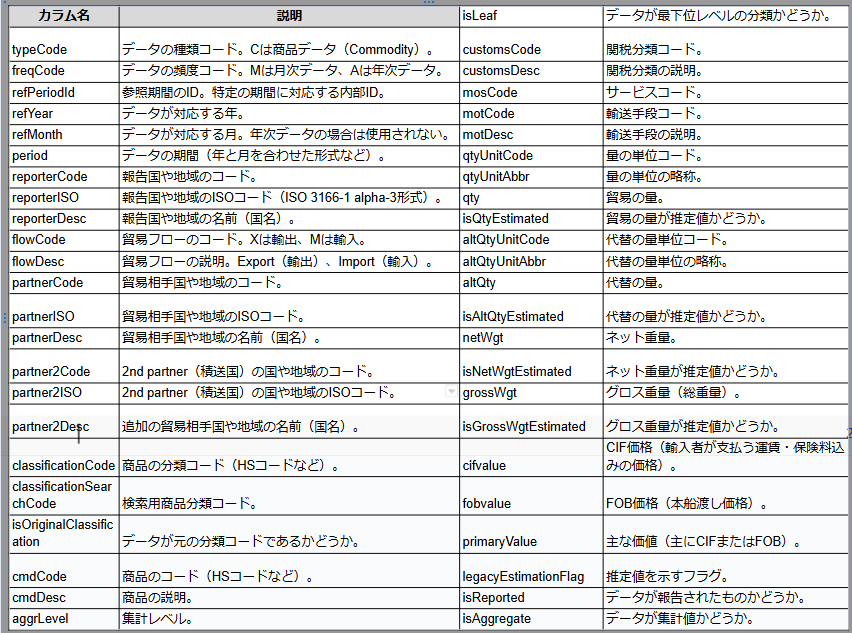

**2nd partner countryについて**
https://uncomtrade.org/docs/second-partner-country/

## 1-2. データ概観

In [286]:
# 列名
print(df.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')


In [287]:
#　データ数
print(df.shape)

(8438, 47)


In [288]:
# 国数
len(df['reporterDesc'].unique())

154

In [289]:
print(df['reporterDesc'].unique())

['Australia' 'Andorra' 'Brazil' 'Bulgaria' 'Cameroon' 'Burundi' 'Cambodia'
 'Myanmar' 'Belarus' 'Bosnia Herzegovina' 'Solomon Isds'
 'Brunei Darussalam' 'Botswana' 'Bolivia (Plurinational State of)'
 'Armenia' 'Barbados' 'Belgium' 'Bangladesh' 'Bahamas' 'Bahrain'
 'Azerbaijan' 'Albania' 'Antigua and Barbuda' 'Algeria' 'Argentina'
 'Austria' 'Dominican Rep.' 'Canada' 'Czechia' 'Benin' 'Sri Lanka' 'China'
 'Chile' 'Cyprus' 'Congo' 'Costa Rica' 'Colombia' 'Croatia' 'Denmark'
 'Dominica' 'French Polynesia' 'France' 'Gambia' 'Georgia'
 'State of Palestine' 'Gabon' 'Estonia' 'Ethiopia' 'Fiji' 'Ecuador'
 'El Salvador' 'Finland' 'Ghana' 'Greece' 'Grenada' 'Greenland' 'Guyana'
 'Guatemala' 'Guinea' 'Germany' 'China, Hong Kong SAR' 'Madagascar'
 'Mexico' 'Mauritius' 'Malta' 'Ireland' 'Malawi' 'Lesotho' 'Kuwait'
 'Kenya' 'Lithuania' 'Malaysia' 'Luxembourg' 'Kazakhstan'
 "Lao People's Dem. Rep." 'Lebanon' 'Kyrgyzstan' 'Rep. of Korea' 'Latvia'
 'Italy' 'Jordan' 'Jamaica' 'Japan' "Côte d'Ivoire" 'Ir

In [290]:
print(df['partnerDesc'].unique())

['Solomon Isds' 'Brunei Darussalam' 'Myanmar' 'Georgia' 'Germany'
 'Djibouti' 'Ghana' 'Kiribati' 'Guam' 'Guinea' 'Other Asia, nes'
 'Mongolia' 'Poland' 'Timor-Leste' 'Burkina Faso' 'World' 'Antarctica'
 'American Samoa' 'Argentina' 'Canada' 'Sri Lanka' 'Chile' 'China'
 'China, Hong Kong SAR' 'Hungary' 'Indonesia' 'Nauru' 'Netherlands'
 'Russian Federation' 'Saudi Arabia' 'Samoa' 'Zambia' 'Areas, nes'
 'Bahrain' 'Bangladesh' 'Belgium' 'Botswana' 'Iraq' 'Ireland' 'Israel'
 'Italy' "Côte d'Ivoire" 'New Caledonia' 'Vanuatu' 'Serbia' 'Sierra Leone'
 'India' 'Viet Nam' 'Brazil' 'Christmas Isds' 'Cocos Isds' 'Colombia'
 'Dem. Rep. of the Congo' 'Czechia' 'Denmark' 'Ecuador' 'Japan' 'Kenya'
 'Rep. of Korea' 'New Zealand' 'Nigeria' 'Norway' 'Singapore' 'Slovenia'
 'South Africa' 'Spain' 'Zimbabwe' 'Suriname' 'United Arab Emirates'
 'Türkiye' 'Eritrea' 'Ethiopia' 'Fiji' 'Finland' 'France' 'Kuwait'
 "Lao People's Dem. Rep." 'Latvia' 'Liberia' 'Lithuania' 'Madagascar'
 'Pakistan' 'Papua New Guinea

今回のデータは11454件、139か国が含まれているが、どのように選んだのか不明なので要改善ではある

## 1-3 欠損値・外れ値処理

In [291]:
df.isnull().sum()

,0
typeCode,0
freqCode,0
refPeriodId,0
refYear,0
refMonth,0
period,0
reporterCode,0
reporterISO,0
reporterDesc,0
flowCode,0


**欠損値が50％以上ある列を削除**

In [292]:
# 欠損値の割合を計算
threshold = 0.5  # 50%以上が欠損している列を削除
df = df.loc[:, df.isna().mean() < threshold]

**reportedDescがWorldの行を削除する**

In [293]:
df = df[df['reporterDesc'] != 'world']
df = df[df['partnerDesc'] != 'world']
# 結果を確認
print(f"Number of rows after filtering: {len(df)}")

Number of rows after filtering: 8438


・小さい値にデータ数が集まっているので、不用意に削除すると鉱物輸出量が少ないだけで主要な国同士とのやり取りである行を削除する恐れがある

・今はデータ数減らしたくない

↓

一旦そのまま使う

# 2. ネットワーク可視化

## 2-1. データをネットワーク構造に落とし込む

### ②ネットワーク本参照

## **▼データ全体のネットワーク化**

In [294]:
# 必要な列のみ抽出（必要に応じて列名を調整）
df = df[["reporterDesc", "partnerDesc", "fobvalue"]]

# FOB値が0以下の場合は除外
df = df[df["fobvalue"] > 0]

# 重複を統一するため、すべてのノード名を小文字に変換
df["reporterDesc"] = df["reporterDesc"].str.lower()
df["partnerDesc"] = df["partnerDesc"].str.lower()

# NetworkXのグラフ作成
G = nx.DiGraph()  # 有向グラフ

# ノードとエッジを追加
for _, row in df.iterrows():
    reporter = row["reporterDesc"]
    partner = row["partnerDesc"]
    weight = row["fobvalue"]

    # ノード追加（重複ノードは自動的に統一）
    G.add_node(reporter)
    G.add_node(partner)

    # エッジ追加（FOB値が0以上の場合のみ）
    if weight > 0:
        G.add_edge(reporter, partner, weight=weight)

# グラフの情報を表示
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 239
Number of edges: 7699


In [295]:
# # グラフの描画
# plt.figure(figsize=(10, 10))
# pos = nx.spring_layout(G, seed=42)  # レイアウトを設定
# nx.draw(
#     G, pos, with_labels=True, node_size=700, node_color="lightblue", font_weight="bold"
# )
# plt.title("Trade Network")
# plt.axis("off")
# plt.show()

## **▼中国を基点としたピラミッド型**

In [296]:
# # 基点ノード
# base_node = 'china'

# # 各ノードのchinaからの距離を計算
# if base_node in G:
#     distances = nx.single_source_shortest_path_length(G, base_node)
# else:
#     raise ValueError(f"'{base_node}' not found in the graph nodes.")

# # 距離に基づいてレイヤーを作成
# layers = {}
# for node, distance in distances.items():
#     if distance not in layers:
#         layers[distance] = []
#     layers[distance].append(node)

# # カスタムレイアウトの計算
# pos = {}
# layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
# for distance in sorted(layers.keys()):
#     layer_nodes = layers[distance]
#     layer_x = 0.5  # x座標の開始点
#     spacing = 1.0 / len(layer_nodes) if len(layer_nodes) > 0 else 1.0  # レイヤー内のノード間の間隔
#     for i, node in enumerate(layer_nodes):
#         pos[node] = (layer_x + i * spacing, layer_y)
#     layer_y -= 0.2  # レイヤーを下げる（y座標）

# # グラフの描画
# # グラフの描画（横幅を広げ、ラベルの文字サイズを調整）
# plt.figure(figsize=(15, 8))  # 横幅を広げる
# nx.draw(
#     G,
#     pos,
#     with_labels=True,
#     node_size=500,
#     node_color="lightblue",
#     font_weight="bold",
#     font_size=8  # ラベルの文字サイズを小さくする
# )
# plt.title("Pyramid Network Layout Based on Distance from 'china'", fontsize=14)
# plt.axis('off')
# plt.show()

二段にしか分かれていないから、おそらく中国を始点としたとき距離３以上の経路がないんだと思う。念のため確認。

In [297]:
# # 基点ノード(china)からの距離を計算
# distances = nx.single_source_shortest_path_length(G, "china")

# # 距離が3以上のノードが存在するか確認
# nodes_distance_3_or_more = {node: dist for node, dist in distances.items() if dist >= 3}

# # 結果を表示
# if nodes_distance_3_or_more:
#     print("Nodes with distance 3 or more from 'china':")
#     for node, distance in nodes_distance_3_or_more.items():
#         print(f"Node: {node}, Distance: {distance}")
# else:
#     print("No nodes with distance 3 or more from 'china'.")

次は終点をアメリカに限定して経路を描画したいけど、計算に時間がかかりすぎるので、中国→アメリカ経路のうち計算時間が現実的なものは距離いくつまで行けるのか計算してみる。
10、5、4とやってみたが4が現実的。

In [298]:
# # 中国からアメリカまで行くすべてのパスを列挙（最大距離を4に制限）
# all_paths = list(nx.all_simple_paths(G, source="china", target="usa", cutoff=4))

# # 最も長いパス（ノード数が最大のパス）を取得
# longest_path = max(all_paths, key=len)

# # 最大パスのエッジ数を計算
# max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# # 結果を表示
# print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
# print(f"Number of edges in the longest path: {max_path_length}")

## **▼始点：中国→終点：アメリカ（距離４以下の経路）：subgraph**

In [299]:
# 基点と終点を設定
source_node = "china"
target_node = "usa"

# 距離4以下の経路を抽出
paths_within_distance = list(nx.all_simple_paths(G, source=source_node, target=target_node, cutoff=4))

# 距離4以下の経路に含まれるすべてのノードを抽出
nodes_within_paths = set(node for path in paths_within_distance for node in path)

# サブグラフを作成（抽出したノードのみ含む）
subgraph = G.subgraph(nodes_within_paths)

# カスタムレイアウトの計算（レイヤー構造にする）
pos = {}
layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
layers = {}
for path in paths_within_distance:
    for distance, node in enumerate(path):
        if distance not in layers:
            layers[distance] = []
        if node not in layers[distance]:
            layers[distance].append(node)

for distance, nodes in sorted(layers.items()):
    layer_x = 0.5  # x座標の開始点
    spacing = 1.0 / len(nodes) if len(nodes) > 0 else 1.0  # レイヤー内のノード間隔
    for i, node in enumerate(nodes):
        pos[node] = (layer_x + i * spacing, layer_y)
    layer_y -= 0.2  # レイヤーを下げる

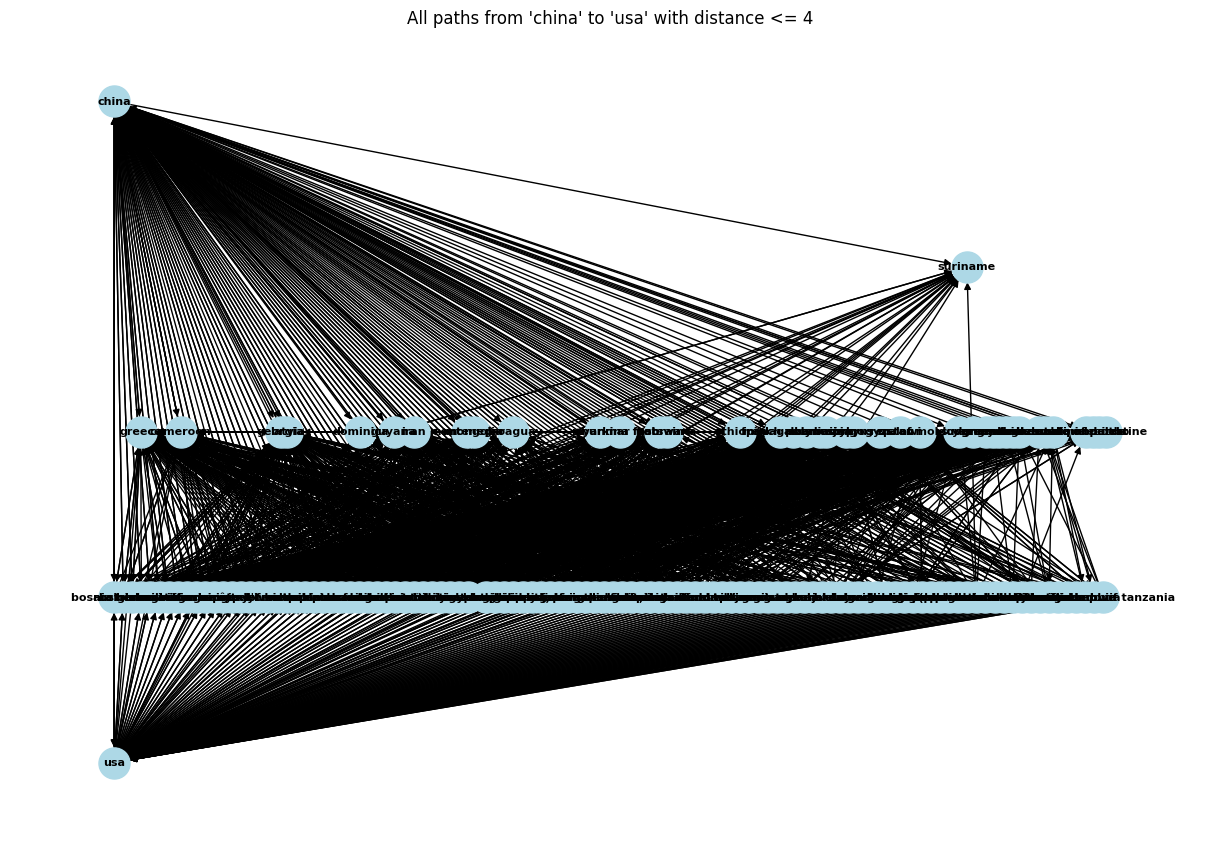

In [300]:
# グラフの描画
plt.figure(figsize=(12, 8))
nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=500,
    node_color="lightblue",
    font_weight="bold",
    font_size=8
)
plt.title(f"All paths from '{source_node}' to '{target_node}' with distance <= 4")
plt.axis('off')
plt.show()

「中国からアメリカまでの距離4以下の経路」はめっちゃある。
たぶんグラフ上のレイヤーが4つにわかれた経路がcentral african repを通るものしかないのは、同じ描画上同じレイヤーの国同士で貿易しているから。

In [301]:
# 中国からアメリカまで行くすべてのパスを列挙（最大距離を4に制限）
all_paths = list(nx.all_simple_paths(subgraph, source="china", target="usa", cutoff=4))

# 最も長いパス（ノード数が最大のパス）を取得
longest_path = max(all_paths, key=len)

# 最大パスのエッジ数を計算
max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# 結果を表示
print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
print(f"Number of edges in the longest path: {max_path_length}")

Longest path from 'china' to 'usa' (with max distance 10): ['china', 'albania', 'bulgaria', 'austria', 'usa']
Number of edges in the longest path: 4


# 2.流入量計算＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊

## Networkxで計算

**閉路を削除する：subgraph→dag**


すべてのサイクルを除去してしまうと、china-usaのループがすべて削除されてしまうので、usa→chinaの向きのエッジを削除してからループを削除する。

**データクリーニングした（欠損値・外れ値削除、始点中国で終点アメリカに設定、閉路削除）DAG（Directed Acyclic Graph：有向非巡回グラフ）をcsv保存しておく：dag→df_cleaned**

In [302]:
print("ノードの数：", nx.number_of_nodes(G))
print("ノードの数：", nx.number_of_nodes(subgraph))
print("データの数 サイクル除去前：", df.shape[0])

ノードの数： 239
ノードの数： 152
データの数 サイクル除去前： 8438


サイクル除去するとデータが減りすぎる。

*   df：全データのデータフレーム
*   G：dfを基にreporter = row["reporterDesc"]、partner = row["partnerDesc"]、weight = row["fobvalue"]で作ったネットワーク
*   subgraph：始点china、終点usaとしたGの部分ネットワーク
*   dag：subgraphからサイクル除去（china→usaに影響しないエッジのみ削除）したもの
*   df_cleaned：dagのエッジリストをデータフレーム化したもの
*   subgraph_cleaned：subgraphからサイクル除去したもの（dag）

In [303]:
def calculate_flow_with_stop_on_target(G, source, target, weight='weight'):
    """
    始点から終点までの流入量を計算し、終点に到達したら計算を終了する関数。
    また、終点から始点へのエッジを削除する。

    Parameters:
        G (nx.DiGraph): 重み付き有向グラフ
        source (str): 始点ノード
        target (str): 終点ノード
        weight (str): 重み属性の名前

    Returns:
        float: 終点への最終流入量
    """
    # 終点から始点へのエッジを削除
    if G.has_edge(target, source):
        G = G.copy()  # オリジナルを変更しないためにコピー
        G.remove_edge(target, source)

    # 初期化: 各ノードの流入量を0に設定
    flow = {node: 0 for node in G.nodes}
    flow[source] = 1  # 始点の流入量を1に設定

    visited = set()  # 訪問済みノードを記録

    def dfs(node):
        if node == target:
            return  # 終点に到達したら終了

        visited.add(node)
        out_edges = G.out_edges(node, data=True)
        total_weight = sum(edge_data[weight] for _, _, edge_data in out_edges)

        if total_weight == 0:  # 出力がない場合
            return

        for _, neighbor, edge_data in out_edges:
            proportion = edge_data[weight] / total_weight
            if neighbor not in visited:
                flow[neighbor] += flow[node] * proportion
                dfs(neighbor)  # 再帰的に隣接ノードを処理

    # DFSを開始
    dfs(source)

    return flow.get(target, 0)

# アメリカへの最終流入量を計算
usa_flow = calculate_flow_with_stop_on_target(subgraph, source="china", target="usa", weight="weight")

# 結果を表示
print(f"The calculated flow into 'usa' from 'china' is: {usa_flow}")

The calculated flow into 'usa' from 'china' is: 0.09879946622735457


In [304]:
# 直接輸出割合を計算（元のサブグラフ）
if subgraph.has_edge(source_node, target_node):
    direct_weight = subgraph[source_node][target_node]["weight"]
    total_source_weight = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges(source_node, data=True))
    direct_export_ratio1 = direct_weight / total_source_weight
else:
    direct_export_ratio1 = 0  # 直接輸出がない場合

# 直接輸出割合を表示
print(f"The direct export ratio from '{source_node}' to '{target_node}' in original subgraph is: {direct_export_ratio1}")

The direct export ratio from 'china' to 'usa' in original subgraph is: 0.09879945269598148


In [305]:
# 直間比率を計算
The_ratio_of_di = direct_export_ratio1 / usa_flow
The_ratio_of_indi = 1 - (direct_export_ratio1 / usa_flow)
Indi_to_di = The_ratio_of_indi / The_ratio_of_di

print("直接輸出の割合", The_ratio_of_di)
print("間接輸出の割合", The_ratio_of_indi)
print("間接・直接の比率", Indi_to_di)

直接輸出の割合 0.9999998630420426
間接輸出の割合 1.3695795741952566e-07
間接・直接の比率 1.3695797617701032e-07


In [306]:
# 中国の全輸出量を計算
if subgraph.has_node("china"):
    china_total_export = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges("china", data=True))
    print(f"China's total export volume: {china_total_export:,}")  # 三桁区切りに変更
else:
    china_total_export = 0
    print("China node does not exist in the graph.")

# アメリカへの最終流入量を推定
usa_final_estimation = usa_flow * china_total_export

# 結果を表示
print(f"The estimated final flow into 'usa' from 'china' is: {usa_final_estimation:,}")  # 三桁区切りに変更


China's total export volume: 13,448,412,858.0
The estimated final flow into 'usa' from 'china' is: 1,328,696,011.975492


In [307]:
# 中国（reporterDescがchina）の行をフィルタリングし、fobvalueの合計を計算
china_total_fobvalue = df[df["reporterDesc"].str.lower() == "china"]["fobvalue"].sum()

# 結果を表示（三桁区切り）
print(f"The total FOB value for 'china' as a reporter: {china_total_fobvalue:,}")


The total FOB value for 'china' as a reporter: 27,185,776,956.0


In [308]:
# サブグラフをデータフレームに変換
subgraph_edges_df = nx.to_pandas_edgelist(subgraph)

# データフレームの先頭を確認
subgraph_edges_df.head()

,source,target,weight
0,australia,solomon isds,682491.0
1,australia,brunei darussalam,8262.0
2,australia,myanmar,94616.0
3,australia,georgia,33320.0
4,australia,germany,28832040.0


そのうち直接輸出はどのくらいの割合なのか

In [309]:
# 一次経由国、二次経由国、三次経由国を取得する関数
def get_transit_countries_with_counts(G, source, target):
    """
    一次経由国、二次経由国、三次経由国を抽出し、各レベルの国数をカウントする関数。

    Parameters:
        G (nx.DiGraph): 有向グラフ
        source (str): 始点ノード（例: "china"）
        target (str): 終点ノード（例: "usa"）

    Returns:
        dict: 各経由国リストとそのカウントを含む辞書
    """
    # ターゲット（アメリカ）への経路のみ抽出
    paths_to_target = [
        path for path in nx.all_simple_paths(G, source=source, target=target, cutoff=4)
    ]

    # 経由国の分類
    transit_countries = {1: set(), 2: set(), 3: set()}
    for path in paths_to_target:
        if len(path) >= 3:
            transit_countries[1].add(path[1])  # 一次経由国
        if len(path) >= 4:
            transit_countries[2].add(path[2])  # 二次経由国
        if len(path) >= 5:
            transit_countries[3].add(path[3])  # 三次経由国

    # 各レベルの国とその数を結果として返す
    return {k: {"countries": list(v), "count": len(v)} for k, v in transit_countries.items()}

# 始点と終点を設定
source_node = "china"
target_node = "usa"

# 経由国を取得
transit_countries_with_counts = get_transit_countries_with_counts(subgraph, source_node, target_node)

# 結果を表示
print("Transit countries:")
for level, data in transit_countries_with_counts.items():
    print(f"{level}st level transit countries ({data['count']} countries): {data['countries']}")


Transit countries:
1st level transit countries (143 countries): ['rep. of korea', 'pakistan', 'costa rica', 'nicaragua', 'fiji', 'state of palestine', 'türkiye', 'serbia', 'kuwait', 'guyana', 'saudi arabia', 'czechia', 'japan', 'trinidad and tobago', 'congo', 'singapore', 'zambia', 'denmark', 'canada', 'kazakhstan', 'egypt', 'cyprus', 'namibia', 'bulgaria', 'cambodia', 'new zealand', 'burundi', 'iceland', 'saint lucia', 'albania', "côte d'ivoire", 'gabon', 'ukraine', 'thailand', 'indonesia', 'switzerland', 'tunisia', 'dominica', 'senegal', 'israel', 'morocco', 'ecuador', 'botswana', 'peru', 'sri lanka', 'mauritius', 'russian federation', 'jordan', 'algeria', 'paraguay', 'oman', 'malta', 'brunei darussalam', 'ethiopia', 'china, hong kong sar', 'ireland', 'brazil', 'spain', 'qatar', 'rep. of moldova', 'poland', 'guatemala', 'bahamas', "lao people's dem. rep.", 'new caledonia', 'viet nam', 'india', 'yemen', 'croatia', 'belarus', 'iran', 'slovakia', 'burkina faso', 'kyrgyzstan', 'el salvad

In [310]:
print("エッジの数（G）", nx.number_of_edges(G))
print("エッジの数（subgraph）", nx.number_of_edges(subgraph))
print("行数（df）", df.shape[0])

エッジの数（G） 7699
エッジの数（subgraph） 6501
行数（df） 8438


直接間接割合がサンクションの時期に本当に増えているのか
間接があるなら、どういう迂回路を作っているのか
うごいた理由をデータから探す

仮説はいままでなかった迂回路


品目を変えて

小麦で

パワポ作る
サンクションの実例とか物語仕立てに見せられるパワポを作る

